**1. (18 points) During the month of September, we see the following number of items delivered via USPS at a particular location: 6, 7, 6, 7, 7, 6, 11, 4, 8, 6, 6, 12, 2, 8, 12, 5, 7, 8, 6, 11, 6, 8, 9, 11, 5, 9, 8, 9, 8, 12**

**(a) We’d like to organize this data into 3 groups, corresponding to high, medium, and low delivery days. Use smoothing by bin means to accomplish this, using a bin depth of 10. Illustrate your steps.**

If you put all the numbers in order and spit it into 3 groups of 10, you get: low: [2,4,5,5,6,6,6,6,6,6], medium: [6,7,7,7,7,8,8,8,8,8], high: [8,9,9,9,11,11,11,12,12,12], when u find the mean of these sets you get low: 5.2, medium: 7.4, and high: 10.4. 

Now the bins are as follows:

Low delivery days: [5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2]

Medium delivery days: [7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4]

High delivery days: [10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4]

**(b) Repeat the steps in part (a), this time using smoothing by bin medians into 3 bins of equal width**

To find the depth of each bin: (12-2)/3 = 3.3
low:[2,4,5,5], medium:[6,6,6,6,6,6,6,7,7,7,78,8,8,8,8,8], high:[9,9,9,11,11,11,12,12,12]. 

The medians of each of these are as follows: 
low: 4.5, medium: 7, high: 11

Now the bins are:

Low delivery days: [4.5, 4.5, 4.5, 4.5]

Medium delivery days: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]

High delivery days: [11, 11, 11, 11, 11, 11, 11, 11, 11]

**(c) Comment on which smoothing method, if any, you would prefer to use for the given data, giving reasons as to why.**

I would prefer to use smoothing by bin medians becasue i feel like the result represents the data better than smoothing by means. I feel this way because the bins have a bigger range, which helps capture more of the data.

**(d) If we apply min-max normalization to the numbers of mailed items onto the range [0.0, 1.0], what would be the transformed value of 5?**

(5-2)/(12-2) = 3/10 = 0.3

The transformed value of 5 would be 0.3.

**(e) If we apply z-score normalization (standardization) to the numbers of mailed items, what is the transformed value of 5?**

All the numbers added together = 230

230/30 = 7.67 = mean

standard deviation = 2.43

z-score: (5-7.67)/2.43 = -1.1

The transformed value of 5 would be -1.1

**(f) Comment on which normalization method, if any, you would prefer to use for the given data, giving reasons as to why.**

I would prefer to use z-score normalization because I can visualize more and get more from it. The z-score normalization tells me that 5 is a little over 1 standard deviation bellow the mean. Where the min-max normalization only tells me 5 is 30% of the way from the minimum to the maximum.

**2.**

**(a) Use the sm.OLS() function to perform a simple linear regression with bikers as the re-sponse and temp as the predictor. Use the summarize() function to print the results.**

In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP.models import summarize

# read in csvs
Bike_day = pd.read_csv('../data/bike+sharing+dataset/day.csv')
Bike_hour = pd.read_csv('../data/bike+sharing+dataset/hour.csv')

# bikers = response, temp = predictor
X = Bike_day[['temp']].copy()     # predictor
y = Bike_day['cnt']               # response

# add intercept column
X['intercept'] = np.ones(Bike_day.shape[0])

# fit OLS model
model = sm.OLS(y, X).fit()


# summarize results
summarize(model)
#print(model.summary())

,coef,std err,t,P>|t|
temp,6640.7100,305.188,21.759,0.0
intercept,1214.6421,161.164,7.537,0.0


**(b) Explain why we can deduce that there is a significant association between the predictor and the response.**

The coeficient for temperature is 6640, which means for each unit increase in temperature the expected # of bikers increased by about 6640 on average. The p-value being 0 allows us the reject the null hypothesis which means it is very unlikely this result is due to random chance.

**(c) How strong is the relationship between the predictor and the response? Use the R2 statistic to support your answer.**

In [24]:
print("R-squared:", model.rsquared)

R-squared: 0.3937487313729242


The relationship between the predictor and the response is strong given it is only one variable. The R-squared value is 0.39 which means around 39% of the variation in bike usage can be explained by temperature. For a single variable, this is a lot.

**(d) Is the relationship between the predictor and the response positive or negative? How can you tell?**

The relationship between the predictor and the response is positive. This can be seen by the fact that the slope coefficient for temperature is positive.

**(e) According to this model, what is the predicted number of bikers on a day that averages the minimum temp?**

In [27]:
print(min(Bike_day['temp']))

0.0591304


interecept coefficient = 1214.64
temp coefficient = 6640.71
minimum avg. temp: 0.0591

1214.64 + (6640.71 * (0.05913)) = 1,607

The predicted number of bikers on a day that averages the minimum temp is 1,607.

**(f) Why might it be inappropriate to use this model to estimate the number of bikers on this day?**

It may be inappropriate to use this model to estimate the number of bikers at the minimum temperature because the model is based on a linear trend across the observed range of temperatures, and very cold days are likely underrepresented in the data. This model also doesn’t account for other factors that affect biking on very cold days, like snow or ice. This makes the prediction less reliable at extreme temperatures.

**(g) Plot the response and the predictor in a new set of axes ax. Use the ax.axline() method or the abline() function defined in the lab to display the least squares regression line.**

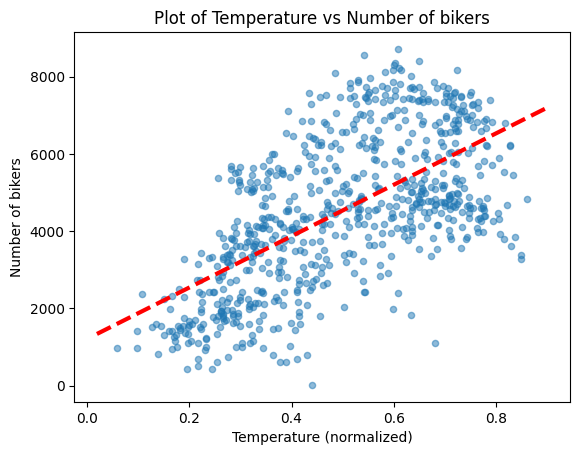

In [38]:
import matplotlib.pyplot as plt

def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

# Scatterplot of temp vs cnt
ax = Bike_day.plot.scatter('temp', 'cnt', alpha=0.5)
ax.set_title("Plot of Temperature vs Number of bikers")
ax.set_xlabel("Temperature (normalized)")
ax.set_ylabel("Number of bikers")

# Regression line
abline(ax,
       model.params['const'],   # intercept
       model.params['temp'],    # slope
       'r--',
       linewidth=3)

**(h) Produce a residual plot which compares the observed bikers values to the predicted ones**